# Full dataset Inter-annotator agreement for speech-level sentiment annotation

The notebook combines the test and main annotation datasets into a single dataframe and calculates Krippendorff's alpha for both the 6-class and 3-class sentiment annotation schemes. Agreement is evaluated on the full dataset as well as on the non-procedural subset (i.e., instances not produced by Chair speakers).

The notebook also visualises inter-annotator agreement across individual annotation phases to track changes in agreement throughout the annotation process.

In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os
import krippendorff

In [2]:
test_files = glob.glob('../Annotations_Tests/Test*/Test*_consolidation.csv')
main_files = glob.glob('../Annotation_Main/Main*/Main*_consolidation.csv')

print(test_files)
print(main_files)
print('No. of test files: ', len(test_files))
print('No. of main files: ', len(main_files))

all_files = test_files + main_files
print(all_files)
print('No. of main files: ', len(all_files))

['../Annotations_Tests/Test1/Test1_consolidation.csv', '../Annotations_Tests/Test3/Test3_consolidation.csv', '../Annotations_Tests/Test2/Test2_consolidation.csv']
['../Annotation_Main/Main4/Main4_consolidation.csv', '../Annotation_Main/Main3/Main3_consolidation.csv', '../Annotation_Main/Main2/Main2_consolidation.csv', '../Annotation_Main/Main5/Main5_consolidation.csv', '../Annotation_Main/Main1/Main1_consolidation.csv']
No. of test files:  3
No. of main files:  5
['../Annotations_Tests/Test1/Test1_consolidation.csv', '../Annotations_Tests/Test3/Test3_consolidation.csv', '../Annotations_Tests/Test2/Test2_consolidation.csv', '../Annotation_Main/Main4/Main4_consolidation.csv', '../Annotation_Main/Main3/Main3_consolidation.csv', '../Annotation_Main/Main2/Main2_consolidation.csv', '../Annotation_Main/Main5/Main5_consolidation.csv', '../Annotation_Main/Main1/Main1_consolidation.csv']
No. of main files:  8


## Agreement for individual annotation phases

The calculation of inter-annotator agreement for individual annotation phases, including both test and main annotation phases (n=1117), to track changes in agreement through phases.

In [3]:
mapping_3class = {
    'Positive': 'Positive',
    'M_Positive': 'Positive',    
    'Negative': 'Negative',
    'M_Negative': 'Negative',
    'P_Neutral': 'Neutral',
    'N_Neutral': 'Neutral',
    }

results = []


def compute_KA_ACC(df, tag_cols, mapping_3class, subset_name):
    #--6-class--#
    tag_to_code6 = {label: idx for idx, label in enumerate(pd.unique(df[tag_cols].values.ravel()))}
    for col in tag_cols:
        df[col + '_6class'] = df[col].map(tag_to_code6)
    data_6class = df[[col + '_6class' for col in tag_cols]].to_numpy().T
    alpha6 = krippendorff.alpha(reliability_data=data_6class, level_of_measurement='nominal')

    #---3-class---
    for col in tag_cols:
        df[col + '_3class'] = df[col].map(mapping_3class)
    tag_to_code3 = {label: idx for idx, label in enumerate(pd.unique(df[[col + "_3class" for col in tag_cols]].values.ravel()))}
    
    for col in tag_cols:
        df[col + '_3code'] = df[col + '_3class'].map(tag_to_code3)
    data_3class = df[[col + '_3code' for col in tag_cols]].to_numpy().T
    alpha3 = krippendorff.alpha(reliability_data=data_3class, level_of_measurement="nominal")

    #----Agreement---#
    def percent_agreement(rows):
        values = [val for val in rows if pd.notnull(val)]
        return int(len(set(values)) == 1)
    
    acc6 = df[tag_cols].apply(percent_agreement, axis=1).mean()
    acc3 = df[[col + '_3class' for col in tag_cols]].apply(percent_agreement, axis=1).mean()

    return {
        f'KA_6_{subset_name}': round(alpha6, 2),
        f'KA_3_{subset_name}': round(alpha3, 2),
        f'ACC_6_{subset_name}': round(acc6 * 100, 1),
        f'ACC_3_{subset_name}': round(acc3 * 100, 1)
    }
    


for file in all_files:
    df = pd.read_csv(file)
    pilot_name = os.path.splitext(os.path.basename(file))[0]
    base_name = pilot_name.split('_')[0]

    
    #Selecting columns with annotation tags (tag_tamara, tag_katja, tag_anze)
    tag_cols = [col for col in df.columns if col.startswith("tag_")]

    #Handle values with added Sarcasm note (Negative(S) -> Negative)
    for col in tag_cols:
        df[col] = df[col].astype("str").str.strip().str.replace(r"\(S\)", "", regex=True)
    
    #KA and ACC for full dataset
    metrics_full = compute_KA_ACC(df.copy(), tag_cols, mapping_3class, 'full')

    #KA and ACC for non-procedural speeches only (i.e. chair != True)
    df_non = df[df['chair'] != True]
    metrics_non = compute_KA_ACC(df_non.copy(), tag_cols, mapping_3class, 'nonproc')

    result_row = {"Phase": base_name}
    result_row.update(metrics_full)
    result_row.update(metrics_non)
    results.append(result_row)


summary = pd.DataFrame(results)
summary['sort_key'] = summary['Phase'].apply(lambda x: 0 if 'Test' in x else 1)
summary = summary.sort_values(by='sort_key').drop(columns='sort_key').reset_index(drop=True)
summary

,Phase,KA_6_full,KA_3_full,ACC_6_full,ACC_3_full,KA_6_nonproc,KA_3_nonproc,ACC_6_nonproc,ACC_3_nonproc
0,Test1,0.84,0.91,89.5,94.7,0.70,0.77,80.0,90.0
1,Test3,0.79,0.83,86.0,90.0,0.66,0.64,76.0,80.0
2,Test2,0.69,0.71,80.0,84.0,0.54,0.51,65.4,69.2
3,Main4,0.74,0.83,82.5,90.5,0.50,0.62,67.0,82.5
4,Main3,0.75,0.89,83.5,93.5,0.61,0.81,75.3,90.7
5,Main2,0.67,0.84,78.5,91.0,0.47,0.70,64.1,83.7
6,Main5,0.75,0.88,84.0,93.5,0.61,0.79,72.6,89.5
7,Main1,0.71,0.83,81.0,90.0,0.63,0.78,72.7,86.9


In [4]:
summary.to_csv('../Tables/KA_Tracking.csv', encoding='utf-8', index=False)


In [5]:
df_ka = summary.melt(id_vars='Phase', value_vars=[col for col in summary.columns if col.startswith('KA')],
                     var_name='Metric', value_name='KA')
df_ka['Scale'] = df_ka['Metric'].apply(lambda x: '6-class' if '_6' in x else '3-class')
df_ka['Condition'] = df_ka['Metric'].apply(lambda x: 'Full' if 'full' in x else 'Non-procedural')

#Order_full = all columns, order = Main only
order_full = ['Test1', 'Test2', 'Test3', 'Main1', 'Main2', 'Main3', 'Main4', 'Main5']
order = ['Main1', 'Main2', 'Main3', 'Main4', 'Main5']

df_ka['Phase'] = pd.Categorical(df_ka['Phase'], categories=order_full, ordered=True)


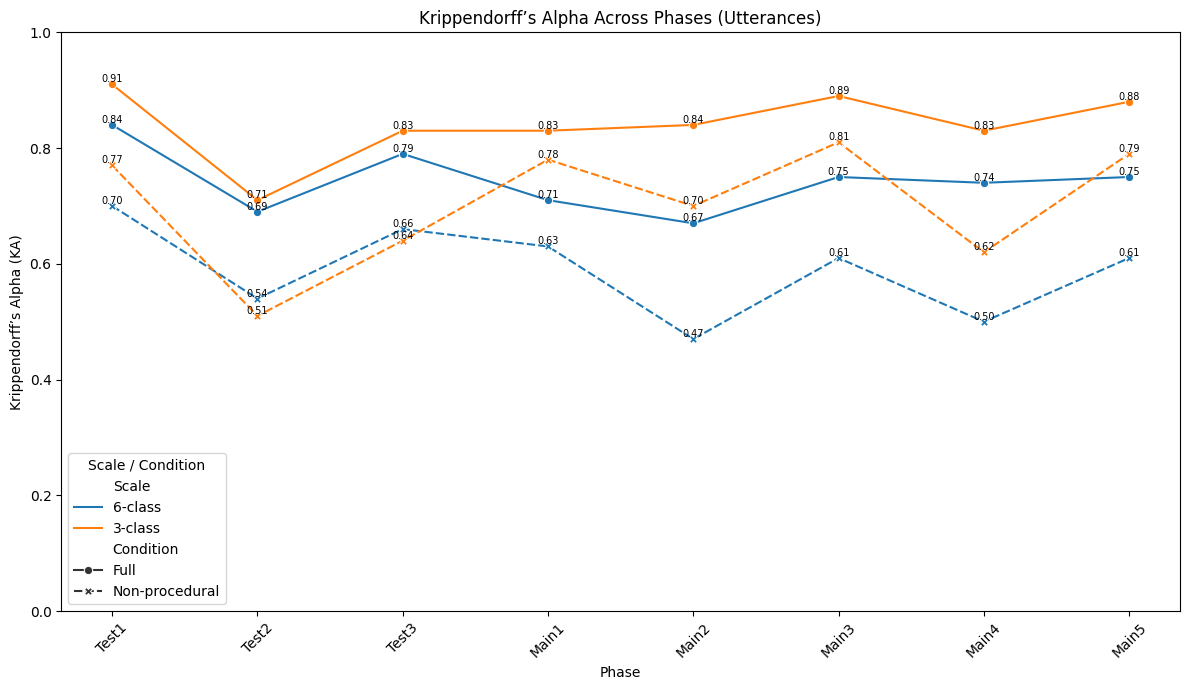

In [6]:
plt.figure(figsize=(12, 7))
lineplot = sns.lineplot(data=df_ka,
             x='Phase', y='KA',
             hue='Scale', style='Condition',
             markers=True, dashes=True)

plt.title("Krippendorff’s Alpha Across Phases (Utterances)")
plt.ylabel("Krippendorff’s Alpha (KA)")
plt.ylim(0, 1) 
plt.xticks(rotation=45)
plt.legend(title='Scale / Condition')

#Adding KA scores to the 
for line in lineplot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data, y_data, f'{y_data:.2f}', fontsize=7, ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../Figures/KA_Utternaces.png', dpi=300)
plt.show()

## Agreement for only main annotation phases (n=1000)

For the ParlSent-SI dataset only uses the annotations, produced within the main annotation phases after several rounds of test annotations (training). Therefore, we evaluate inter-annotator agreement also for the main annotations only (n=1000), for both 6- and 3-class annotations. 

Additionally, we report Krippendorff's &alpha; for the non-procedural subset as well.

In [7]:
df = pd.concat([pd.read_csv(file) for file in main_files], ignore_index=True)

df = df.drop(columns='Unnamed: 0')
df

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,chair,final_tag,sent_tamara,sent_katja,agreement_tag,agreement_sent
0,ParlaMint-SI_2013-11-22-SDZ6-Redna-19.u93,"Hvala lepa tudi vam. Gospod Mihael Prevc, nasl...",P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,True,P_Neutral,Neutral,Neutral,NaN,NaN
1,ParlaMint-SI_2015-01-26-SDZ7-Redna-04.u152,"Hvala lepa za besedo. Spoštovane ministrice, m...",M_Negative,M_Negative,"Divided, valid questions.","First two sentences seem to be positive, howev...",NaN,1.0,False,M_Negative,Negative,Negative,NaN,NaN
2,ParlaMint-SI_2006-11-29-SDZ4-Redna-22.u165,"Kolega Slavko Gaber, v temu trenutku vam lahko...",P_Neutral,P_Neutral,Procedural. I guess could be N_Neutral but its...,NaN,NaN,NaN,True,P_Neutral,Neutral,Neutral,NaN,NaN
3,ParlaMint-SI_2001-03-01-SDZ3-Redna-03.u116,"Moram replicirati. Kolega Moge - ne moram, amp...",M_Positive,Negative,"Clealry a defensive response, but positive.",Speaker presents arguments on why the proposal...,NaN,NaN,False,NaN,Positive,Negative,NaN,NaN
4,ParlaMint-SI_2021-12-16-SDZ8-Redna-28.u22,"Hvala za besedo, podpredsednica. Lep pozdrav v...",Positive,Positive,"Support, but also positive parts presented.",At the end there is a slight negative connotat...,NaN,NaN,False,Positive,Positive,Positive,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,ParlaMint-SI_2009-07-10-SDZ5-Redna-08.u230,Hvala lepa za besedo. Poslanci DeSUS predlagan...,Negative,Negative,"Not supporting the core of the talk, supportin...",Explicit opitnion of the speaker/party that th...,NaN,NaN,False,Negative,Negative,Negative,NaN,NaN
996,ParlaMint-SI_2006-07-14-SDZ4-Redna-19.u56,[[...]]se zgodijo nepravilnosti in jaz si ne ž...,M_Positive,M_Positive,"Second part positive and first part negative, ...",NaN,NaN,NaN,False,M_Positive,Positive,Positive,NaN,NaN
997,ParlaMint-SI_2008-06-16-SDZ4-Redna-40.u121,Hvala lepa. Zelo podobno vprašanje je gospa po...,M_Negative,Negative,Although there are some positive stuff written...,Very defensive answer on a question - I would ...,NaN,True,False,NaN,Negative,Negative,NaN,NaN
998,ParlaMint-SI_2021-03-30-SDZ8-Izredna-67.u29,"Hvala lepa. Kolega Cigler, replika.",P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,True,P_Neutral,Neutral,Neutral,NaN,NaN


### Agreement -- Main only (n=1000), full dataset



In [8]:
#6-class IAA calculations

tag_cols = ['tag_tamara', 'tag_katja']

# Keep only items annotated by both annotators
tags = df[tag_cols].copy()

unique_tags = pd.unique(tags.values.ravel())
unique_tags = [x for x in unique_tags if pd.notna(x)]

tag_to_code = {label: idx for idx, label in enumerate(unique_tags)}

for col in tag_cols:
    tags[col + '_6class'] = tags[col].map(tag_to_code)

data_6class = tags[[col + '_6class' for col in tag_cols]].to_numpy(dtype=float).T

alpha_6class = krippendorff.alpha(
    reliability_data=data_6class,
    level_of_measurement='nominal'
)

ka_6class = round(alpha_6class, 3)
print("KA 6-class:", ka_6class)

KA 6-class: 0.724


In [9]:
#3-class IAA calculations

mapping_3class = {
    'Positive': 'Positive',
    'M_Positive': 'Positive',    
    'Negative': 'Negative',
    'M_Negative': 'Negative',
    'P_Neutral': 'Neutral',
    'N_Neutral': 'Neutral',
    }

for col in tag_cols:
    df[col + '_3class'] = df[col].map(mapping_3class)

unique_tag3 = pd.unique(df[[col + "_3class" for col in tag_cols]].values.ravel())
unique_tag3 = [x for x in unique_tag3 if pd.notna(x)]

tag_to_code3 = {label: idx for idx, label in enumerate(unique_tag3)}

for col in tag_cols:
    df[col + '_3code'] = df[col + '_3class'].map(tag_to_code3)

data_3class = df[[col + '_3code' for col in tag_cols]].to_numpy().T

alpha_3class = krippendorff.alpha(
    reliability_data=data_3class, 
    level_of_measurement="nominal")


ka_3class= round(alpha_3class, 3)
print("KA 3-class score: ", ka_3class)

KA 3-class score:  0.853


In [10]:
def percent_agreement_complete(rows):
    if rows.isna().any():
        return np.nan
    return int(len(set(rows)) == 1)

agreement_6 = (
    df[tag_cols]
    .apply(percent_agreement_complete, axis=1)
    .mean()
)

agreement_3 = (
    df[[col + '_3class' for col in tag_cols]]
    .apply(percent_agreement_complete, axis=1)
    .mean()
)

acc_6class= round((agreement_6 * 100),2)
acc_3class= round((agreement_3 * 100),2)


print("Agreement for a 6-class schema: ", acc_6class)
print("Agreement for a 3-class schema: ", acc_3class)

Agreement for a 6-class schema:  81.9
Agreement for a 3-class schema:  91.7


### Agreement -- Main only (n=1000), non-procedural subset

In [11]:
non_df = df[df['chair'] != True]
df.head()

print(len(df)) ## Should be 480 

1000


In [12]:
#6-class IAA calculations

tag_cols = ['tag_tamara', 'tag_katja']

# Keep only items annotated by both annotators
tags = non_df[tag_cols].copy()

unique_tags = pd.unique(tags.values.ravel())
unique_tags = [x for x in unique_tags if pd.notna(x)]

tag_to_code = {label: idx for idx, label in enumerate(unique_tags)}

for col in tag_cols:
    tags[col + '_6class'] = tags[col].map(tag_to_code)

data_6class = tags[[col + '_6class' for col in tag_cols]].to_numpy(dtype=float).T

alpha_6class = krippendorff.alpha(
    reliability_data=data_6class,
    level_of_measurement='nominal'
)

ka_non_6class = round(alpha_6class, 3)

print("KA non-procedural 6-class:", ka_non_6class)

KA non-procedural 6-class: 0.571


In [13]:
#3-class IAA calculations

mapping_3class = {
    'Positive': 'Positive',
    'M_Positive': 'Positive',    
    'Negative': 'Negative',
    'M_Negative': 'Negative',
    'P_Neutral': 'Neutral',
    'N_Neutral': 'Neutral',
    }

non_df = non_df.copy()

for col in tag_cols:
    non_df[col + '_3class'] = non_df[col].map(mapping_3class)

unique_tag3 = pd.unique(non_df[[col + "_3class" for col in tag_cols]].values.ravel())
unique_tag3 = [x for x in unique_tag3 if pd.notna(x)]

tag_to_code3 = {label: idx for idx, label in enumerate(unique_tag3)}

for col in tag_cols:
    non_df[col + '_3code'] = non_df[col + '_3class'].map(tag_to_code3)

data_3class = non_df[[col + '_3code' for col in tag_cols]].to_numpy().T

alpha_3class = krippendorff.alpha(
    reliability_data=data_3class, 
    level_of_measurement="nominal")


ka_non_3class = round(alpha_3class, 3)

print("KA non-procedural 3-class: ", ka_non_3class)

KA non-procedural 3-class:  0.745


In [14]:
agreement_6 = (
    non_df[tag_cols]
    .apply(percent_agreement_complete, axis=1)
    .mean()
)

agreement_3 = (
    non_df[[col + '_3class' for col in tag_cols]]
    .apply(percent_agreement_complete, axis=1)
    .mean()
)

acc_non_6class = round((agreement_6 * 100),2)
acc_non_3class = round((agreement_3 * 100),2)

print("Agreement for a non-procedural 6-class subset: ", acc_non_6class)
print("Agreement for a non-procedural 3-class subset: ", acc_non_3class)

Agreement for a non-procedural 6-class subset:  70.42
Agreement for a non-procedural 3-class subset:  86.67


In [15]:
results6 = {
    ("final_tag", "ACC"): acc_6class,
    ("final_tag", "Kripp. alpha"): ka_6class,
    ("final_tag non-procedural", "ACC"): acc_non_6class,
    ("final_tag non-procedural", "Kripp. alpha"): ka_non_6class,
}

results3 = {
    ("final_tag3", "ACC"): acc_3class,
    ("final_tag3", "Kripp. alpha"): ka_3class,
    ("final_tag3 non-procedural", "ACC"): acc_non_3class,
    ("final_tag3 non-procedural", "Kripp. alpha"): ka_non_3class,
}

df6 = pd.DataFrame({
    "Subset":["Full", 'Non-procedural'],
    "ACC": [acc_6class, acc_non_6class],
    "Kripp. alpha": [ka_6class, ka_non_6class]
})

df6

,Subset,ACC,Kripp. alpha
0,Full,81.90,0.724
1,Non-procedural,70.42,0.571


In [16]:
df3 = pd.DataFrame({
    "Subset":["Full", 'Non-procedural'],
    "ACC": [acc_3class, acc_non_3class],
    "Kripp. alpha": [ka_3class, ka_non_3class]
})

df3

,Subset,ACC,Kripp. alpha
0,Full,91.70,0.853
1,Non-procedural,86.67,0.745


# Final tag distribution

Analysis of the sentiment label distributions for 6- and 3-class schema, both for full dataset, as well as for non-procedural subset.

In [17]:
df = pd.read_csv('../Datasets/Annotations.csv') ## Dataset with final (consolidated) sentiment tags 
df = df.drop(columns=['Unnamed: 0'])
df

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,sent_tamara,sent_katja,chair,final_tag
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.u90,"Ni replike na repliko. Gospa ministrica, potem...",N_Neutral,N_Neutral,"Procedural, but he is denying her the ability ...","Procedural, however still has relatively stron...",NaN,NaN,Neutral,Neutral,True,N_Neutral
1,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.u107,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,P_Neutral,P_Neutral,Procedural.,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.u178,"Hvala lepa. V bistvu se strinjam z vami, gospo...",Positive,Positive,Speaker is stating positive changes and support.,"Speech seems to be fairly positive, as the spe...",NaN,NaN,Positive,Positive,False,Positive
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.u276,"Hvala, podpredsednik. Hvala tudi za vprašanje,...",Negative,Negative,"Negative opinion of the topic, the work done, ...",Could also be Mixed sentiment due to the last ...,NaN,1.0,Negative,Negative,False,Negative
4,ParlaMint-SI_2009-11-18-SDZ5-Redna-11.u120,Besedo ima gospod Silven Majhenič.,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...
995,ParlaMint-SI_2015-05-13-SDZ7-Izredna-13.u1,Spoštovani kolegice poslanke in kolegi poslanc...,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral
996,ParlaMint-SI_2001-10-05-SDZ3-Redna-08.u73,"O amandmaju k 26. členu nismo glasovali, ker s...",P_Neutral,N_Neutral,Procedural,NaN,NaN,NaN,Neutral,Neutral,False,P_Neutral
997,ParlaMint-SI_2005-02-01-SDZ4-Izredna-06.u95,"Hvala, gospodu Kovačiču. Da se ne bi še kdo zm...",P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral
998,ParlaMint-SI_2009-03-27-SDZ5-Redna-04.u199,Hvala lepa. Besedo ima mag. Branko Grims. Prosim.,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral


In [18]:
tags = df['final_tag'].value_counts()
tags

final_tag
P_Neutral     505
Negative      275
M_Positive     62
N_Neutral      57
M_Negative     54
Positive       47
Name: count, dtype: int64

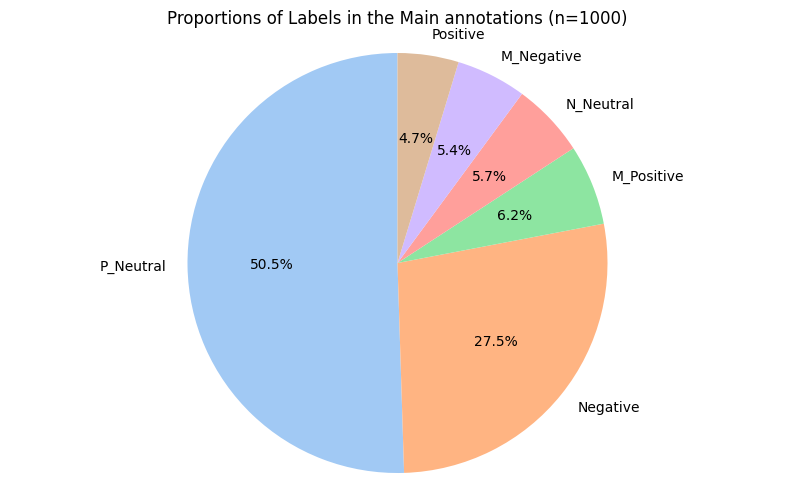

In [19]:
palette = sns.color_palette('pastel')
plt.figure(figsize=(10,6))
plt.title('Proportions of Labels in the Main annotations (n=1000)')
plt.pie(tags, labels=tags.index, colors=palette, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.savefig('../Figures/Label_proportions_Main.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
tags_non = df[df['chair'] == False] #Remove chair speeches
tags_non = tags_non.value_counts('final_tag')
tags_non

final_tag
Negative      258
M_Positive     61
M_Negative     54
Positive       47
P_Neutral      41
N_Neutral      19
Name: count, dtype: int64

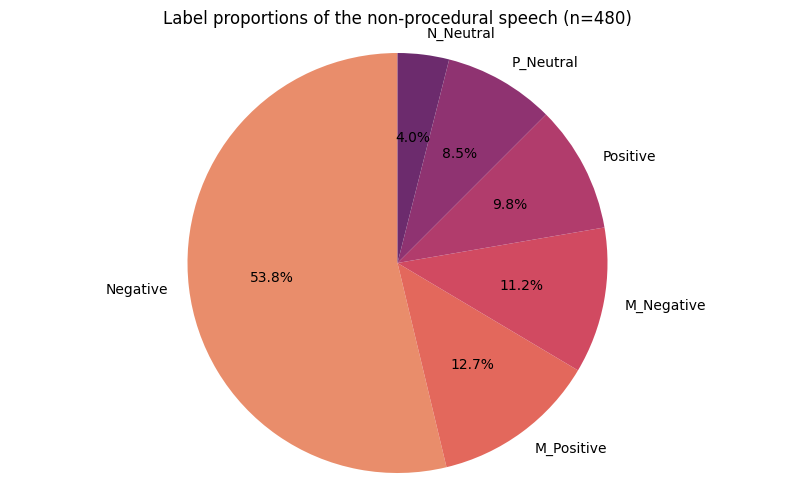

In [21]:
palette2 = sns.color_palette('flare')
plt.figure(figsize=(10,6))
plt.title('Label proportions of the non-procedural speech (n=480)')

plt.pie(tags_non, labels=tags_non.index, colors=palette2, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.savefig('../Figures/Non-procedural_Labels_pie.png', dpi=300, bbox_inches='tight')
plt.show()

### Non-procedural subset

In [22]:
#Add new column "final_tag3" with "aggregated" lables (Positive, Negative, Neutral)
df.loc[(df['final_tag'] == 'Negative') | (df['final_tag'] == 'M_Negative'), 'final_tag3'] = 'Negative'
df.loc[(df['final_tag'] == 'Positive') | (df['final_tag'] == 'M_Positive'), 'final_tag3'] = 'Positive'
df.loc[(df['final_tag'] == 'N_Neutral') | (df['final_tag'] == 'P_Neutral'), 'final_tag3'] = 'Neutral'
df.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,sent_tamara,sent_katja,chair,final_tag,final_tag3
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.u90,"Ni replike na repliko. Gospa ministrica, potem...",N_Neutral,N_Neutral,"Procedural, but he is denying her the ability ...","Procedural, however still has relatively stron...",NaN,NaN,Neutral,Neutral,True,N_Neutral,Neutral
1,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.u107,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,P_Neutral,P_Neutral,Procedural.,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral,Neutral
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.u178,"Hvala lepa. V bistvu se strinjam z vami, gospo...",Positive,Positive,Speaker is stating positive changes and support.,"Speech seems to be fairly positive, as the spe...",NaN,NaN,Positive,Positive,False,Positive,Positive
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.u276,"Hvala, podpredsednik. Hvala tudi za vprašanje,...",Negative,Negative,"Negative opinion of the topic, the work done, ...",Could also be Mixed sentiment due to the last ...,NaN,1.0,Negative,Negative,False,Negative,Negative
4,ParlaMint-SI_2009-11-18-SDZ5-Redna-11.u120,Besedo ima gospod Silven Majhenič.,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,Neutral,Neutral,True,P_Neutral,Neutral


In [23]:
tags3 = df.value_counts('final_tag3')
tags3

final_tag3
Neutral     562
Negative    329
Positive    109
Name: count, dtype: int64

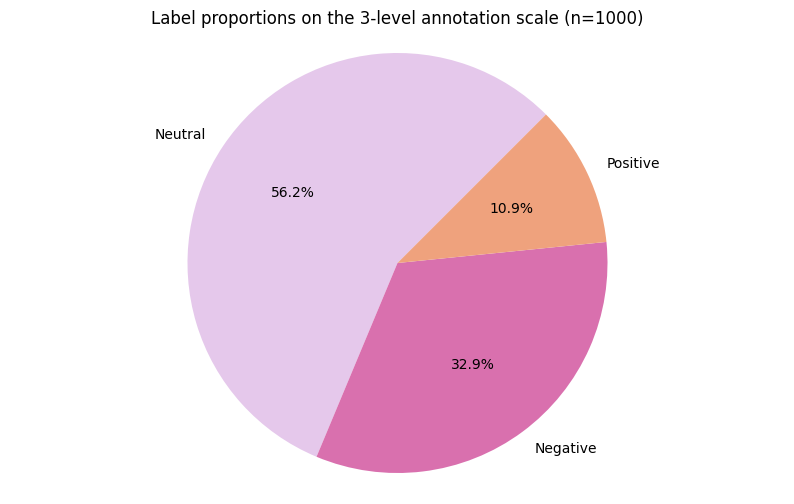

In [24]:
custom_palette = ['#E5C8EB', '#D970AE', '#EFA27D']
sns.set_palette(custom_palette)
plt.figure(figsize=(10,6))
plt.title('Label proportions on the 3-level annotation scale (n=1000)')
plt.pie(tags3, labels=tags3.index, colors=custom_palette, autopct='%1.1f%%', startangle=45)
plt.axis('equal')
plt.savefig('../Figures/Labels_3-level_pie.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
df_non = df[df['chair'] == False]
tags3_non = df_non.value_counts('final_tag3')
tags3_non

final_tag3
Negative    312
Positive    108
Neutral      60
Name: count, dtype: int64

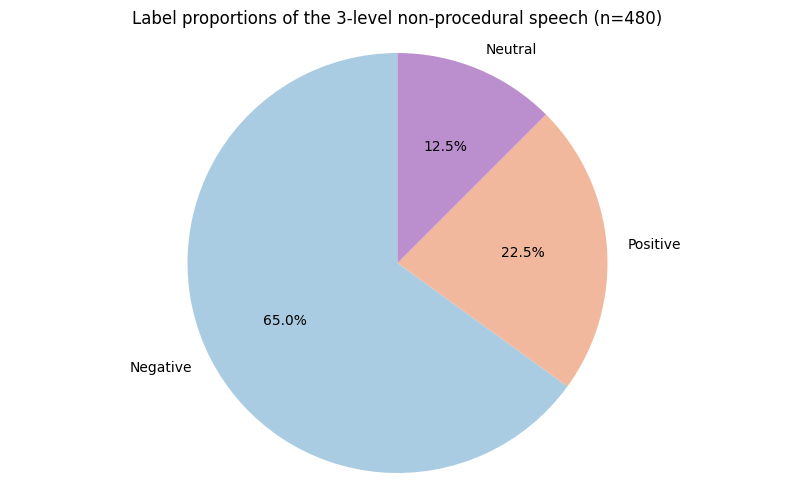

In [27]:
new = ['#A9CCE3', '#F1B89D', '#BB8FCE']
palette4 = sns.set_palette(new)
plt.figure(figsize=(10, 6))
plt.title('Label proportions of the 3-level non-procedural speech (n=480)')

plt.pie(tags3_non, labels=tags3_non.index, autopct='%1.1F%%', startangle=90, colors=palette4)
plt.axis('equal')
plt.savefig('../Figures/Labels_3-level_nonprocedural_pie.png', dpi=300, bbox_inches='tight')

plt.show()